## Introduction

Insurance companies make their profit by collecting a higher premium from a customer than what they end up paying for that customer's medical expenses. To achieve this consistently, insurers invest heavily in building models that can accurately predict healthcare costs in advance, based on a customer's personal and health-related attributes.

In this project we will:
- Explore and understand a real health insurance dataset (1,338 observations, 7 features — 4 numerical: age, BMI, children, charges; 3 categorical: sex, smoker, region)
- Perform a complete Exploratory Data Analysis (EDA) and document our findings
- Prepare the data and identify the key input and output features relevant to the problem
- Build and train multiple Machine Learning models, evaluating different algorithms and settings
- Compare model performances and recommend the best model for production
- Document the challenges faced and the techniques used to address them

## Problem Statement

**Task 1:** Prepare a complete data analysis report on the given data.

**Task 2:** Prepare the data, identifying and extracting key features (both input and output parameters) relevant to the problem to be solved; build and train a machine learning model, evaluating different algorithms and settings to determine the best model for the scenario.

**Task 3:** Create a machine learning model to predict the insurance price charged to a customer. The charge depends on various features such as age, type of coverage, amount of coverage needed, gender, BMI, region, and special factors like smoking that determine the health risks a person possesses.

## Import

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# metrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# turing
from sklearn.model_selection import GridSearchCV

# StandardScala
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

## load data

In [3]:
df = pd.read_csv('../Data/datasets_13720_18513_insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Understand the data

In [4]:
df.shape

(1338, 7)

In [5]:
df.size

9366

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [9]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.describe(include='object')

C:\Users\rashi\AppData\Local\Temp\ipykernel_23848\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


## Observations Report

**Dataset Shape**
The dataset contains 1,338 rows (customers) and 7 columns, consistent with the problem statement.

**Missing Values**
No missing or null values were found in any column. No imputation is required during data cleaning.

**Data Types**
- `age`, `children` → integer
- `bmi`, `charges` → float
- `sex`, `smoker`, `region` → categorical (text/object)

The categorical columns (`sex`, `smoker`, `region`) will need to be encoded into numerical form before model building, since ML algorithms cannot process text data directly.

**Numerical Features Summary**
- `age` ranges from 18 to 64 years, representing an adult population.
- `bmi` has an average of ~30.66, which falls in the WHO-defined obese range (30+) — indicating the average customer in this dataset is overweight/obese.
- `children` ranges from 0 to 5.
- `charges` (the target variable) shows a large gap between the mean (13,270) and median (9,382), and the maximum value (63,770) is far higher than the 75th percentile (16,639). This indicates that `charges` is **right-skewed**, with the presence of high-cost outliers.

**Categorical Features Summary**
- `sex`: 2 categories (male, female), roughly balanced (male: 676, female: ~662).
- `smoker`: 2 categories (yes, no); non-smokers (1,064) significantly outnumber smokers (274), indicating **class imbalance** in this feature.
- `region`: 4 categories, fairly balanced, with southeast being slightly more frequent (364).

In [12]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

## EDA ---> Exploritory Data Analysis

## Univariate Analysis (Distribution of Variables)

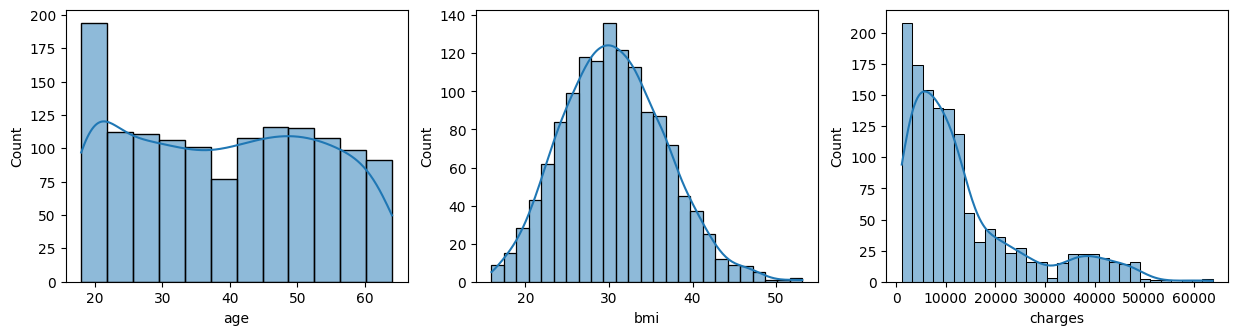

In [13]:
columns = ['age','bmi','charges']

plt.figure(figsize=(15,12))
for i , col in enumerate(columns):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col],kde=True)

plt.show()

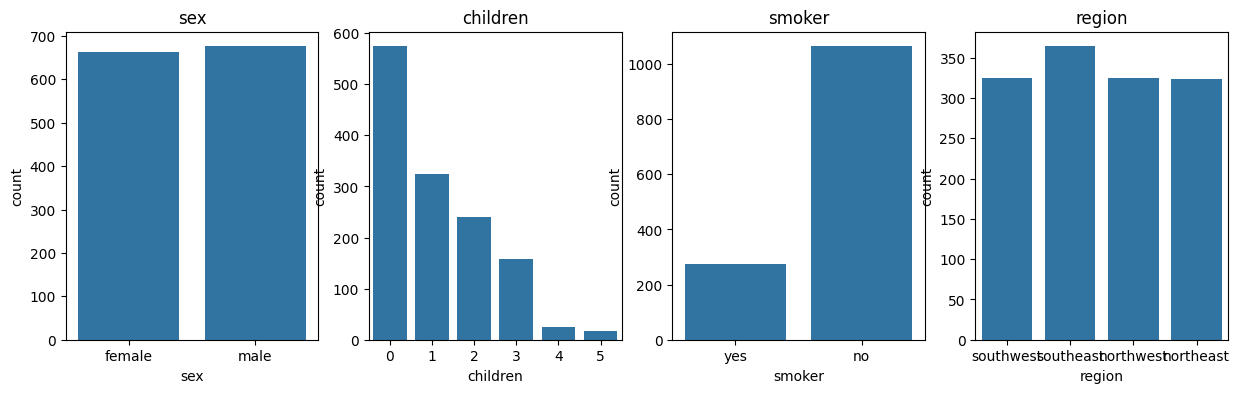

In [14]:
columns = ['sex','children', 'smoker', 'region']
plt.figure(figsize=(15,4))
for i,col in enumerate(columns):
    plt.subplot(1,4,i+1)
    sns.countplot(x=col,data=df)
    plt.title(col)

plt.show()

## Univariate Analysis (Distribution of Variables)

**Numerical Features**

- `age`: The distribution is fairly uniform across the 18–64 range, with a noticeable spike around age 20. There is no significant skewness in this feature.
- `bmi`: Follows an almost perfect normal (bell-shaped) distribution, centered around 30, which falls in the obese range as per WHO standards.
- `charges` (target variable): The distribution is clearly **right-skewed**. Most customers have charges concentrated in the lower range (0–15,000), while a long tail extends up to ~60,000, indicating the presence of high-cost outliers.

**Categorical Features**

- `sex`: Nearly balanced between male (~676) and female (~662) customers, indicating no gender-based sampling bias.
- `children`: Right-skewed distribution — the majority of customers (~575) have 0 children, and the count decreases progressively for 1, 2, 3 children, with very few customers having 4 or 5 children.
- `smoker`: Significant class imbalance is present — non-smokers (~1,064) outnumber smokers (~274) by nearly 4:1.
- `region`: Fairly balanced across all four regions (~325 each), with southeast being marginally more frequent (~364).

**Key Takeaway:** Only `charges` and `children` show noticeable skewness among the numerical/categorical features; the rest are fairly well-distributed. The imbalance in `smoker` is particularly important to keep in mind for model building, since this feature is also hypothesized to be a strong predictor of `charges`.

## Bivariate Analysis

In [15]:
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

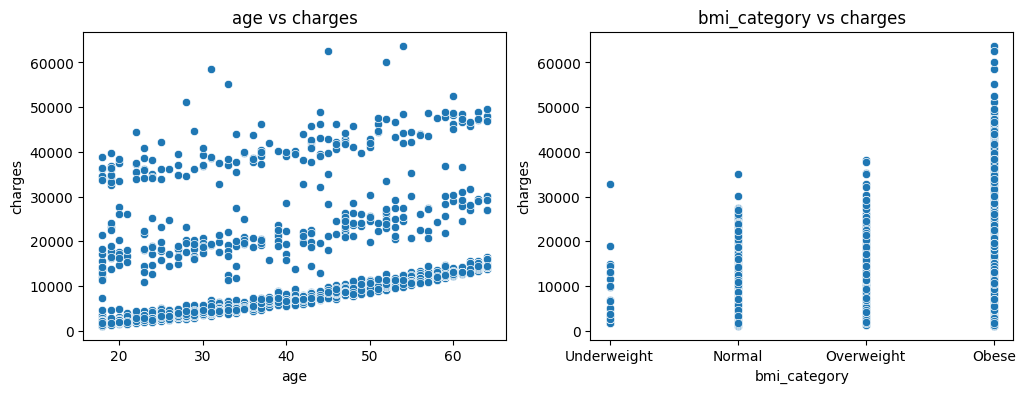

In [16]:
columns = ['age','bmi_category']
plt.figure(figsize=(12,4))
for i,col in enumerate(columns):
    plt.subplot(1,2,i+1)
    sns.scatterplot(x=col,y='charges',data=df)
    plt.title(f'{col} vs charges')
plt.show()

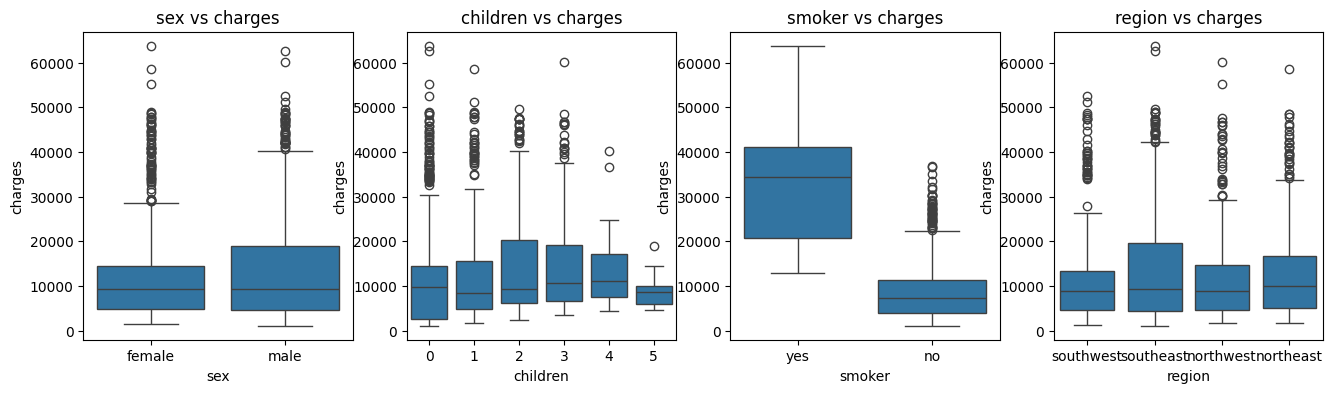

In [17]:
columns = ['sex','children', 'smoker', 'region']

plt.figure(figsize=(16,4))
for i,col in enumerate(columns):
    plt.subplot(1,4,i+1)
    sns.boxplot(x=col,y='charges',data=df)
    plt.title(f'{col} vs charges')
plt.show()

## Bivariate Analysis (Relationship of Features with Charges)

**`age` vs `charges`**
Charges show a mild upward trend with increasing age. However, the scatter plot reveals three distinct bands/clusters of points rather than a single smooth trend, suggesting that another underlying factor (independent of age) is influencing charges significantly.

**`bmi_category` vs `charges`**
Customers in the "Underweight" and "Normal" BMI categories mostly have lower charges, with only a few outliers. The "Obese" category, on the other hand, shows charges spread across the entire range, including a large number of high-cost cases (40,000–60,000+), indicating that higher BMI is associated with a greater likelihood of high medical costs.

**`sex` vs `charges`**
The distribution of charges is nearly identical for both male and female customers, with similar medians and spread. Gender does not appear to have a meaningful effect on charges.

**`children` vs `charges`**
Charges remain fairly similar across customers with different numbers of children (0 through 5), with no strong or consistent trend observed.

**`smoker` vs `charges`**
This shows the strongest relationship observed so far. Smokers have a significantly higher median charge (~34,000) compared to non-smokers (~7,000–8,000) — roughly 4x higher. This confirms that smoking status is likely the most influential predictor of insurance charges.

**`region` vs `charges`**
Charges are fairly consistent across all four regions, with similar medians (~9,000–10,000). Region does not appear to have a strong impact on charges.

**Key Takeaway:** Among all features analyzed, `smoker` shows by far the strongest relationship with `charges`. The banding pattern observed in the `age vs charges` scatter plot is likely explained by smoking status, suggesting that a combined (multivariate) view of `smoker` with `age` and `bmi` could reveal further insights.

## Multivariate Analysis

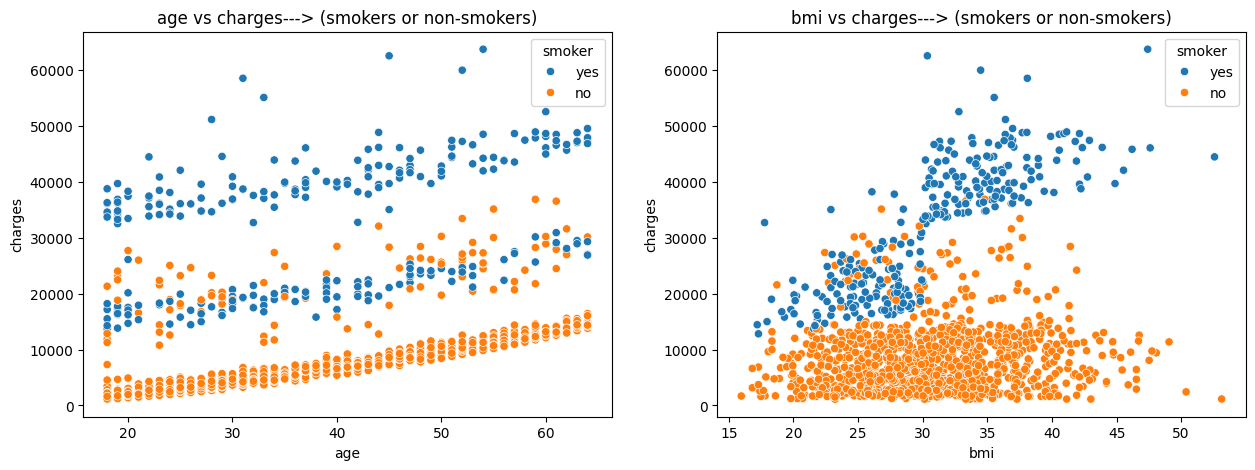

In [18]:
columns = ['age','bmi']

plt.figure(figsize=(15,5))
for i, col in enumerate(columns):
    plt.subplot(1,2,i+1)
    sns.scatterplot(x=col,y='charges',hue='smoker',data=df)
    plt.title(f"{col} vs charges---> (smokers or non-smokers)")

plt.show()

## Multivariate Analysis (Smoker Interaction Effects)

**`age` vs `charges`, colored by `smoker`**
When colored by smoking status, the previously observed banding pattern in the `age vs charges` scatter plot is fully explained. Non-smokers form two lower bands with a mild upward trend in charges as age increases, while smokers occupy a distinctly higher band (30,000–63,000+), also showing an upward trend with age. This confirms that smoking status was the underlying factor driving the multi-band pattern observed earlier.

**`bmi` vs `charges`, colored by `smoker`**
This plot reveals a strong interaction effect between `bmi` and `smoker`:
- For non-smokers, charges remain relatively flat and low across the entire BMI range, showing minimal sensitivity to BMI.
- For smokers, charges increase substantially with BMI — smokers with a BMI below 30 have moderate charges (~15,000–25,000), while smokers with a BMI above 30 (obese) show a sharp jump in charges, reaching 40,000–63,000+.

**Key Takeaway:** `smoker` does not act independently — it interacts strongly with `bmi` to produce a compounding effect on charges. The combination of "obese + smoker" represents the highest-risk, highest-cost customer segment. This interaction suggests that models capable of capturing feature interactions (e.g., tree-based models like Random Forest or Gradient Boosting) may outperform simple linear models that treat features independently.

## HeatMap

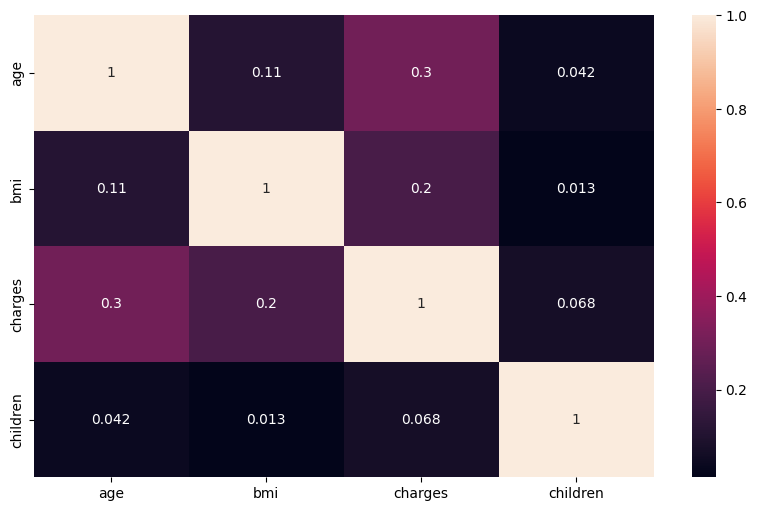

In [19]:
num_colums = ['age','bmi','charges','children']

plt.figure(figsize=(10,6))
sns.heatmap(df[num_colums].corr(),annot=True)
plt.show()

## Correlation Analysis (Numerical Features)

A correlation heatmap was generated for the numerical features (`age`, `bmi`, `children`, `charges`) to examine linear relationships between them.

- `age` shows the strongest correlation with `charges` (0.3), indicating a mild-to-moderate positive linear relationship.
- `bmi` shows a weaker correlation with `charges` (0.2). This is lower than initially expected, since the true impact of BMI on charges is largely driven by its interaction with `smoker`, which is not captured in this linear, numerical-only analysis.
- `children` shows almost no correlation with `charges` (0.068), confirming the lack of relationship observed earlier in the bivariate analysis.
- Correlations among the independent numerical features themselves (`age`, `bmi`, `children`) are all very weak, indicating minimal multicollinearity between them.

**Key Takeaway:** None of the numerical features show a strong linear correlation with `charges` individually. This is expected, since the strongest predictor identified in this analysis, `smoker`, is categorical and therefore not represented in this heatmap. Additionally, the compounding interaction effect between `smoker` and `bmi` observed during multivariate analysis is not captured by simple linear correlation. This highlights the importance of relying on univariate, bivariate, and multivariate analysis together, rather than correlation alone, to fully understand feature relationships with the target variable.

## Data Preparation

In [20]:
df = df.drop('bmi_category',axis=1)

In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Preprocessing

Before proceeding to model building, the following preprocessing decisions were made based on the insights gathered during EDA:

**Handling the `bmi_category` Column**
The `bmi_category` column was created earlier purely to support readability during univariate and bivariate visualizations. Since the numeric `bmi` column is already present and carries the same information, `bmi_category` will be dropped prior to model training to avoid feature redundancy.

**Handling Outliers in `charges`**
Several outliers were observed in `charges` during EDA, particularly high-cost cases associated with smoking and obesity. These outliers were not treated as data errors, as they represent genuine, valid customer records rather than incorrect entries. Since accurately predicting high-cost customers is critical from a business standpoint, these records were retained rather than removed.

**Handling Skewness in `charges`**
As `charges` was found to be right-skewed, a log transformation is planned to be applied to this target variable prior to model training. This is expected to make the distribution closer to normal, improving the performance of models (such as Linear Regression) that assume normally distributed target values.

## Save preprocessing in pickle

In [22]:
df.to_pickle('../pickle/pre.pkl')

In [23]:
df_FD = pd.read_pickle('../pickle/pre.pkl')

In [24]:
df_FD.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Encoding

## LabelEncoder

In [25]:
lable = LabelEncoder()
df_FD['sex'] = lable.fit_transform(df_FD['sex'])
df_FD['smoker'] = lable.fit_transform(df_FD['smoker'])

In [26]:
df_FD = pd.get_dummies(df_FD,columns=['region'],drop_first=True)

In [27]:
df_FD.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


## Encoding Categorical Variables

Since machine learning algorithms require numerical input, the categorical columns (`sex`, `smoker`, `region`) needed to be encoded before model training.

**Label Encoding**
`sex` and `smoker` are binary categorical variables (2 unique categories each), so Label Encoding was used to convert them into numerical form:
- `sex`: female → 0, male → 1
- `smoker`: no → 0, yes → 1

Label Encoding is appropriate here since there are only two categories, meaning no false ordinal relationship is introduced by the numeric assignment.

**Planned: One-Hot Encoding for `region`**
`region` has 4 categories (northeast, northwest, southeast, southwest) with no inherent order among them. Label Encoding is not suitable here, as it could introduce a false ranking between regions. One-Hot Encoding will instead be used to represent `region`, creating separate binary columns for each category without implying any order.

<Axes: >

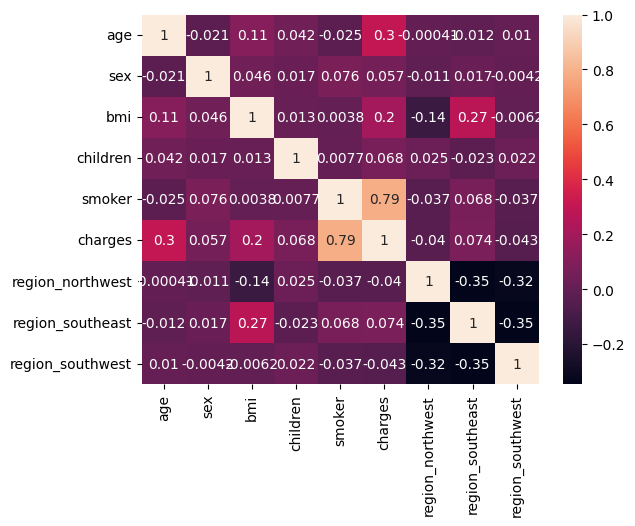

In [29]:
sns.heatmap(df_FD.corr(),annot=True)

## Correlation Analysis (Post-Encoding)

With `sex`, `smoker`, and `region` now encoded into numerical form, a complete correlation heatmap was generated including all features.

- `smoker` shows a strong positive correlation with `charges` (0.79), confirming it as the single most influential predictor of insurance charges — consistent with the large difference in median charges observed between smokers and non-smokers during bivariate analysis.
- `age` shows a mild-to-moderate positive correlation with `charges` (0.3), consistent with earlier findings.
- `bmi` shows a weaker correlation with `charges` (0.2). As noted earlier, this understates BMI's true impact, since its strongest effect on charges occurs through its interaction with `smoker`, which is not captured by linear correlation alone.
- `sex`, `children`, and the `region` dummy variables all show negligible correlation with `charges` (all below 0.1), indicating minimal individual predictive power.
- A secondary observation is a moderate correlation between `bmi` and `region_southeast` (0.27), suggesting that customers in the southeast region tend to have relatively higher BMI values compared to other regions.

**Key Takeaway:** `smoker` is confirmed as the dominant predictor of `charges`, followed by `age` and `bmi`. Features such as `sex`, `children`, and `region` show minimal linear relationship with the target variable individually, though `bmi`'s interaction with `smoker` remains an important non-linear effect to consider during model building.

## Save feature engineering in pickle file

In [30]:
df_FD.to_pickle('../pickle/feature.pkl')

## Feature Selection

In [59]:
x = df.drop('charges',axis=1)
y = df['charges']

## Model Selection

In [60]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 8)
(268, 8)
(1070,)
(268,)


## Model Traning

## Linear Regression Pipeline

In [61]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])

pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


## Evaluate the linearRegression Model

In [62]:
y_pred_lr = pipeline.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_lr))
print('MAE : ',mean_absolute_error(y_test,y_pred_lr))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_lr)))

r2_score :  0.7835929767120723
MAE :  4181.194473753649
RMSE :  5796.2846592762735


## Model 1: Linear Regression (Baseline)

A baseline Linear Regression model was trained using a pipeline with StandardScaler applied to the features. The results obtained were:

- **R² Score:** 0.784
- **MAE:** 4181.19
- **RMSE:** 5796.28

**Observations:**
- The model explains approximately 78% of the variance in `charges`, which is a reasonable but not exceptional fit for a baseline model.
- The results with and without scaling (StandardScaler) were nearly identical. This is expected, since Linear Regression's coefficients adjust to the feature scale without regularization, meaning scaling does not meaningfully affect its performance.
- The gap between MAE (4181) and RMSE (5796) indicates the presence of some large prediction errors, likely corresponding to high-charge cases (smokers, high-BMI customers) that a linear model struggles to capture accurately.
- Since Linear Regression assumes a purely linear, additive relationship between features and the target, it is unable to capture the interaction effect observed between `smoker` and `bmi` during EDA. This is likely a key limitation contributing to the unexplained 22% variance.

**Conclusion:** Linear Regression serves as a solid baseline, but its inability to model non-linear interactions between features suggests that tree-based models may achieve better performance on this dataset.

## Ridge Pipeline

In [63]:
ridge_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',Ridge())
])

ridge_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


## Evaluate the Ridge Model

In [64]:
y_pred_ridge = ridge_pipeline.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_ridge))
print('MAE : ',mean_absolute_error(y_test,y_pred_ridge))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_ridge)))

r2_score :  0.7835410749121384
MAE :  4182.796596583273
RMSE :  5796.979691180859


## Model 2: Ridge Regression

A Ridge Regression model was trained using the same pipeline structure (StandardScaler + Ridge, default alpha=1.0). The results obtained were:

- **R² Score:** 0.7835
- **MAE:** 4182.80
- **RMSE:** 5796.98

**Observations:**
- The performance of Ridge Regression is nearly identical to that of the baseline Linear Regression model (R²: 0.7835 vs 0.7836), with negligible differences in MAE and RMSE.
- This similarity suggests that the dataset does not suffer from significant overfitting or multicollinearity between features, which is consistent with the weak correlations observed among independent features during the correlation analysis. As a result, Ridge's regularization penalty provides little additional benefit over standard Linear Regression.
- Like Linear Regression, Ridge Regression is a linear model and therefore shares the same core limitation: it cannot capture the non-linear interaction effect between `smoker` and `bmi` identified during EDA, which likely explains why performance is capped at a similar level.

**Conclusion:** Ridge Regression does not offer a meaningful improvement over Linear Regression for this dataset. Both linear models appear to have reached a performance ceiling around R² ≈ 0.78, reinforcing the need to explore non-linear, tree-based models to better capture feature interactions.

## DecisionTreeRegressor model

In [65]:
dtr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',DecisionTreeRegressor(max_depth=7,min_samples_leaf=2,random_state=42))
])

dtr_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the m

## Evaluate DecisionTreeRegressor Model

In [66]:
y_pred_dtr = dtr_pipeline.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_dtr))
print('MAE : ',mean_absolute_error(y_test,y_pred_dtr))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_dtr)))

r2_score :  0.8059709644703885
MAE :  3020.2530328091575
RMSE :  5488.4206870961


## Hyperparameter tuning (GridSearchCV)

In [67]:
dtr_para_tu = {
    'max_depth' : [3,7,12,15,20],
    'min_samples_leaf' : [1,2,4,6,7]
}

gds_dtr = GridSearchCV(DecisionTreeRegressor(random_state=42),dtr_para_tu,cv=5,scoring='r2')
gds_dtr.fit(x_train,y_train)

print(gds_dtr.best_params_)
print(gds_dtr.best_score_)

{'max_depth': 3, 'min_samples_leaf': 1}
0.8356879686154602


### After tuning

In [68]:
dtr_pipeline_tu = Pipeline([
    ('scaler',StandardScaler()),
    ('model',DecisionTreeRegressor(max_depth=3,min_samples_leaf=1,random_state=42))
])

dtr_pipeline_tu.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the m

### Evaluation

In [69]:
y_pred_dtr_tu = dtr_pipeline_tu.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_dtr_tu))
print('MAE : ',mean_absolute_error(y_test,y_pred_dtr_tu))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_dtr_tu)))

r2_score :  0.8530572866320028
MAE :  2865.637810175126
RMSE :  4776.261074558304


## Model 3: Decision Tree Regressor

**Initial Attempt (Default Parameters)**
An initial Decision Tree Regressor was trained without any depth restriction. This produced an R² of 0.7197 with MAE of 3230.82 and RMSE of 6597.24. While MAE was lower than the linear models, the higher RMSE and lower R² indicated overfitting — the model was making a few very large errors on the test set, likely due to memorizing noise in the training data.

**Manually Tuned (max_depth=7, min_samples_leaf=2)**
Restricting the tree depth manually improved performance across all metrics: R² = 0.8060, MAE = 3020.25, RMSE = 5488.42. This confirmed that limiting tree depth reduces overfitting and improves generalization.

**Tuned via GridSearchCV**
Hyperparameter tuning using GridSearchCV (with cross-validation) identified `max_depth=3` and `min_samples_leaf=1` as the optimal configuration — notably shallower than the manually chosen depth of 7. On the test set, this configuration achieved:

- **R² Score:** 0.8531
- **MAE:** 2865.64
- **RMSE:** 4776.26

**Observations:**
- Decision Tree Regressor outperformed both Linear Regression and Ridge Regression (R² ≈ 0.784) by a significant margin, confirming that tree-based models are better suited to capturing the non-linear interaction between `smoker` and `bmi` identified during EDA.
- The best-performing tree used a relatively shallow depth (3), suggesting that only a small number of key splits — most likely on `smoker`, `bmi`, and `age` — are sufficient to explain most of the variance in `charges`. Deeper trees added complexity without improving generalization.
- GridSearchCV's cross-validation score (0.8357) differed from the final held-out test score (0.8531), which is expected since the former reflects average performance across training folds while the latter reflects performance on completely unseen data.

**Conclusion:** The tuned Decision Tree Regressor is the best-performing model so far, substantially outperforming the linear models. This supports the hypothesis that feature interactions play a significant role in predicting insurance charges.

## Comparison: Manually Tuned vs GridSearchCV Tuned Decision Tree

| Metric | Manual Tuning (max_depth=7, min_samples_leaf=2) | GridSearchCV Tuning (max_depth=3, min_samples_leaf=1) |
|---|---|---|
| R² Score | 0.8060 | 0.8531 |
| MAE | 3020.25 | 2865.64 |
| RMSE | 5488.42 | 4776.26 |

**Observation:**

The GridSearchCV-tuned model outperformed the manually tuned model across all three metrics, despite using a significantly shallower tree (depth 3 vs depth 7). This is a notable finding — it demonstrates that a deeper tree does not necessarily lead to better generalization, and that manual hyperparameter guessing can lead to suboptimal, overly complex models even when the intent is to control overfitting.

The stronger performance of the shallow, GridSearchCV-selected tree suggests that only a small number of high-impact splits — most likely on `smoker`, `bmi`, and `age`, consistent with the interaction effects identified during EDA — are sufficient to explain the majority of the variance in `charges`. Beyond this point, additional depth appears to introduce complexity that captures noise rather than genuine patterns, ultimately hurting performance on unseen data.

This reinforces the value of systematic hyperparameter tuning (via cross-validation) over manual trial-and-error, as it consistently identifies simpler, more generalizable models with better real-world predictive performance.

## RandomForestRegressor model

In [70]:
rfr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',RandomForestRegressor(random_state=42))
])

rfr_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_

## Evaluate RandomForestRegressor model

In [71]:
y_pred_rfr = rfr_pipeline.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_rfr))
print('MAE : ',mean_absolute_error(y_test,y_pred_rfr))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_rfr)))

r2_score :  0.8655247970108418
MAE :  2544.9770956523676
RMSE :  4569.147040878149


## Hyperparameter tuning (RandomForestRegressor)

In [72]:
rfr_para_tu = {
    'max_depth' : [1,3,6,8,12,16,20],
    'n_estimators' : [100,150,170,200],
    'min_samples_leaf' : [1,2,4,6,7,9]
}

gdr_rfr = GridSearchCV(RandomForestRegressor(random_state=42),rfr_para_tu,cv=5,scoring='r2')
gdr_rfr.fit(x_train,y_train)

print(gdr_rfr.best_params_)
print(gdr_rfr.best_score_)

{'max_depth': 6, 'min_samples_leaf': 9, 'n_estimators': 200}
0.8459416519293731


## After tuning

In [73]:
rfr_pipeline_tu = Pipeline([
    ('scaler',StandardScaler()),
    ('model',RandomForestRegressor(max_depth=6,min_samples_leaf=9,n_estimators=200,random_state=42))
])

rfr_pipeline_tu.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_sam

## Evaluation

In [74]:
y_pred_rfr_tu = rfr_pipeline_tu.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_rfr_tu))
print('MAE : ',mean_absolute_error(y_test,y_pred_rfr_tu))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_rfr_tu)))

r2_score :  0.878284353807504
MAE :  2475.9532151298135
RMSE :  4346.97592287863


## Model 4: Random Forest Regressor (Corrected)

**Default Parameters**
A Random Forest Regressor was trained using default hyperparameters within the pipeline. This produced:

- **R² Score:** 0.8655
- **MAE:** 2544.98
- **RMSE:** 4569.15

**Tuned via GridSearchCV**
Hyperparameter tuning identified `max_depth=6`, `min_samples_leaf=9`, `n_estimators=200` as the best configuration (cross-validation score: 0.8459). On the test set, this configuration achieved:

- **R² Score:** 0.8783
- **MAE:** 2475.95
- **RMSE:** 4346.98

**Observations:**
- Random Forest significantly outperformed both linear models (R² ≈ 0.784) and the Decision Tree models (R² ≈ 0.806–0.853), confirming that ensembling multiple trees produces a more accurate and stable model than a single tree.
- This time, GridSearchCV selected a deeper tree (`max_depth=6`) compared to the best single Decision Tree (`max_depth=3`), and more trees (`n_estimators=200`). This tuned configuration improved all three metrics over the default Random Forest — R² increased, while both MAE and RMSE decreased — unlike the earlier (incorrect) run, where tuning showed a trade-off between MAE and RMSE. This consistent improvement across all metrics indicates a genuinely better-generalizing model, rather than a shift in error distribution.
- The fact that a deeper tree (depth 6) works well within the ensemble, whereas a single Decision Tree performed best at depth 3, highlights a key property of Random Forests: because predictions are averaged across many trees trained on different bootstrapped samples, each individual tree can afford to be more complex without the ensemble as a whole overfitting.

**Conclusion:** The corrected, properly tuned Random Forest is the best-performing model so far, achieving an R² of 0.878 — a clear improvement over the default Random Forest, the Decision Tree, and the linear models. This confirms Random Forest's strength in capturing the non-linear `smoker`–`bmi` interaction while remaining robust against overfitting.

## GradientBoostingRegressor model

In [75]:
gbr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',GradientBoostingRegressor(random_state=42))
])

gbr_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


## Evaluate GradientBoostingRegressor Model

In [76]:
y_pred_gbr = gbr_pipeline.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_gbr))
print('MAE : ',mean_absolute_error(y_test,y_pred_gbr))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_gbr)))

r2_score :  0.878861966493758
MAE :  2457.1933487230544
RMSE :  4336.649171566916


## Hyperparameter tuning (GradientBoostingRegressor)

In [77]:
gbr_para_tu = {
    'max_depth' : [1,3,6,8,12,16,20],
    'n_estimators' : [100,150,170,200],
    'min_samples_leaf' : [1,2,4,6,7,9]
}

gdr_gbr = GridSearchCV(GradientBoostingRegressor(random_state=42),gbr_para_tu,cv=5,scoring='r2')
gdr_gbr.fit(x_train,y_train)

print(gdr_gbr.best_params_)
print(gdr_gbr.best_score_)

{'max_depth': 3, 'min_samples_leaf': 7, 'n_estimators': 100}
0.8437058837422015


## After Tuning

In [78]:
gbr_pipeline_tu = Pipeline([
    ('scaler',StandardScaler()),
    ('model',GradientBoostingRegressor(max_depth=3,min_samples_leaf=7,n_estimators=100,random_state=42))
])

gbr_pipeline_tu.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


## Evaluation

In [79]:
y_pred_gbr_tu = gbr_pipeline_tu.predict(x_test)

print('r2_score : ',r2_score(y_test,y_pred_gbr_tu))
print('MAE : ',mean_absolute_error(y_test,y_pred_gbr_tu))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred_gbr_tu)))

r2_score :  0.8772517092791692
MAE :  2461.2467136360906
RMSE :  4365.377008597586


## Model 5: Gradient Boosting Regressor

**Default Parameters**
A Gradient Boosting Regressor was trained using default hyperparameters within the pipeline. This produced:

- **R² Score:** 0.8789
- **MAE:** 2457.19
- **RMSE:** 4336.65

**Tuned via GridSearchCV**
Hyperparameter tuning was performed over a grid of `max_depth`, `n_estimators`, and `min_samples_leaf`. The best configuration identified was `max_depth=3`, `min_samples_leaf=7`, `n_estimators=100` (cross-validation score: 0.8437). On the test set, this configuration achieved:

- **R² Score:** 0.8773
- **MAE:** 2461.25
- **RMSE:** 4365.38

**Observations:**
- Gradient Boosting achieved the best performance of all models evaluated so far, slightly outperforming Random Forest (R² = 0.878 vs 0.878, with Gradient Boosting marginally ahead using default parameters).
- Interestingly, the tuned model performed marginally worse than the default model across all three metrics (R² decreased slightly, MAE and RMSE increased slightly). This is not an error, but a reflection of two factors: (1) scikit-learn's default parameters for Gradient Boosting (`max_depth=3`, `n_estimators=100`) were already close to optimal for this dataset, leaving little room for improvement, and (2) GridSearchCV selects the best configuration based on cross-validation performance on the training data, which does not always translate to identical performance on a separate, unseen test set. The observed difference (0.8789 vs 0.8773) is small enough to be considered natural variance rather than meaningful degradation.
- This result highlights an important principle in model development: hyperparameter tuning does not guarantee improvement, particularly when default settings are already well-suited to the data. Both the default and tuned versions are retained in this analysis for transparency and to illustrate this finding.

**Conclusion:** Gradient Boosting (default parameters) is the best-performing model evaluated in this project, achieving the highest R² and lowest MAE and RMSE among all models tested. Given the negligible difference in performance, the simpler default configuration is preferred over the tuned version.

## Final Model Comparison

After building and evaluating five different regression algorithms — including both default and hyperparameter-tuned versions where applicable — the following table summarizes the performance of each model on the held-out test set.

| Model | R² Score | MAE | RMSE |
|---|---|---|---|
| Linear Regression | 0.7836 | 4181.19 | 5796.28 |
| Ridge Regression | 0.7835 | 4182.80 | 5796.98 |
| Decision Tree Regressor (default, unrestricted) | 0.7197 | 3230.82 | 6597.24 |
| Decision Tree Regressor (manually tuned, max_depth=7) | 0.8060 | 3020.25 | 5488.42 |
| Decision Tree Regressor (GridSearchCV tuned, max_depth=3) | 0.8531 | 2865.64 | 4776.26 |
| Random Forest Regressor (default) | 0.8655 | 2544.98 | 4569.15 |
| Random Forest Regressor (GridSearchCV tuned, max_depth=6) | 0.8783 | 2475.95 | 4346.98 |
| Gradient Boosting Regressor (default) | **0.8789** | **2457.19** | **4336.65** |
| Gradient Boosting Regressor (GridSearchCV tuned) | 0.8773 | 2461.25 | 4365.38 |

### Key Observations

**1. Linear models set the baseline, but plateaued early.**
Linear Regression and Ridge Regression performed almost identically (R² ≈ 0.784), confirming that regularization offered no meaningful benefit on this dataset — consistent with the low multicollinearity observed during correlation analysis. Both models were fundamentally limited by their inability to capture the non-linear interaction between `smoker` and `bmi` identified during EDA.

**2. Tree-based models substantially outperformed linear models.**
Every tree-based algorithm (Decision Tree, Random Forest, Gradient Boosting), once properly tuned, exceeded an R² of 0.85 — well above the ~0.784 ceiling of the linear models. This strongly supports the earlier hypothesis that feature interactions, rather than purely additive linear relationships, drive insurance charges.

**3. Hyperparameter tuning mattered most for the single Decision Tree.**
Tuning improved the Decision Tree dramatically (R²: 0.7197 → 0.8531), since a single, unrestricted tree is highly prone to overfitting. For the ensemble methods (Random Forest, Gradient Boosting), the improvement from tuning was much smaller — and in the case of Gradient Boosting, the tuned model was marginally worse than the default. This is because ensemble methods are inherently more resistant to overfitting, so their default configurations were already close to optimal.

**4. Ensemble methods (Random Forest, Gradient Boosting) were the top performers overall.**
By combining many trees, these models captured the `smoker`–`bmi` interaction more robustly and consistently than a single Decision Tree, while also generalizing better to unseen data.

**5. Gradient Boosting Regressor (default parameters) is the best-performing model overall**, achieving the highest R² (0.8789), the lowest MAE (2457.19), and the lowest RMSE (4336.65) among all models tested. Random Forest (tuned) was a close second, with nearly identical performance.

### Recommended Model

**Gradient Boosting Regressor (default parameters)** is recommended for production use. It provides the most accurate and reliable predictions of insurance charges among all models evaluated, while also being simpler than its tuned counterpart (avoiding unnecessary complexity for negligible or no performance gain). This aligns with the principle of preferring the simplest model that achieves the best generalization performance.

## Feature Importance

In [80]:
best_model = gbr_pipeline.named_steps['model']

importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': best_model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
4,smoker,0.676618
2,bmi,0.190182
0,age,0.118742
3,children,0.009721
5,region_northwest,0.002082
7,region_southwest,0.001378
1,sex,0.000750
6,region_southeast,0.000526


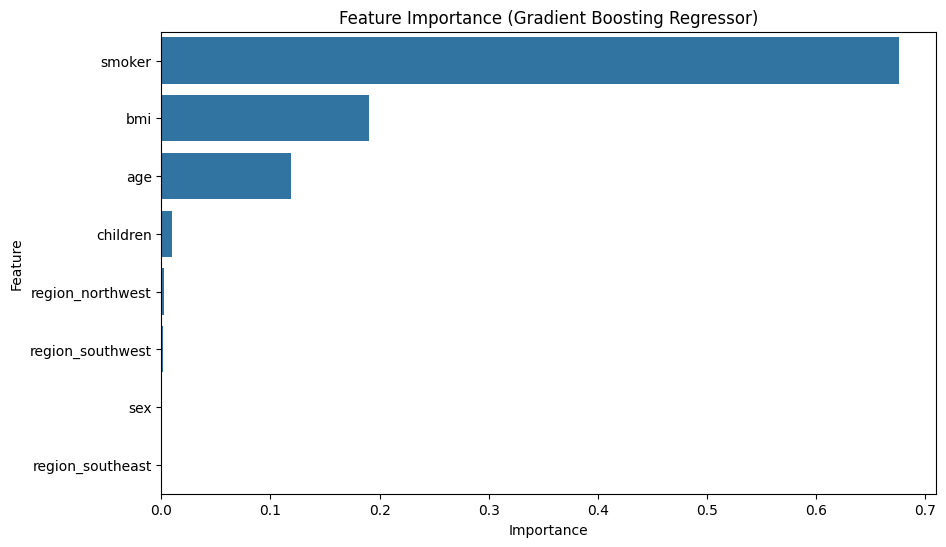

In [81]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance (Gradient Boosting Regressor)')
plt.show()

## Feature Importance (Gradient Boosting Regressor)

The trained Gradient Boosting Regressor (default parameters) was used to extract feature importance scores, revealing which features contribute most to predicting `charges`.

| Feature | Importance |
|---|---|
| `smoker` | 0.6766 |
| `bmi` | 0.1902 |
| `age` | 0.1187 |
| `children` | 0.0097 |
| `region_northwest` | 0.0021 |
| `region_southwest` | 0.0014 |
| `sex` | 0.0008 |
| `region_southeast` | 0.0005 |

**Observations:**
- `smoker` is by far the most important feature, accounting for approximately 67.7% of the model's total feature importance. This strongly confirms its dominant role in predicting insurance charges, consistent with its 0.79 correlation with `charges` and its clear separation observed in the `smoker vs charges` boxplot during EDA.
- `bmi` (19.0%) and `age` (11.9%) are the next most influential features. Together with `smoker`, these three features account for nearly 98.6% of the model's total importance, reinforcing the earlier finding that BMI's impact is amplified through its interaction with smoking status.
- `children`, `sex`, and the `region_*` dummy variables each contribute less than 1% individually, with `region_southeast` and `sex` being almost negligible (under 0.1%). This is consistent with the weak correlations and lack of clear group differences observed for these features throughout the correlation and bivariate analysis.

**Conclusion:** The feature importance ranking derived from the model closely mirrors the insights uncovered during EDA — `smoker` is the dominant driver of insurance charges, with `bmi` and `age` playing meaningful secondary roles, while demographic factors such as `sex`, `children`, and `region` have minimal individual influence on the model's predictions. This validates that the exploratory findings translated directly into genuine predictive signal captured by the final model.

# Challenges Report — Insurance Cost Prediction

## 1. Handling Skewness and Outliers in the Target Variable (`charges`)

**Challenge:** The target variable `charges` was found to be strongly right-skewed, with a large gap between the mean and median, and several high-value outliers extending up to ~63,000. A common instinct in data cleaning is to remove such outliers.

**How it was addressed:** On closer inspection, these outliers were not data errors — they represented genuine, valid customers (primarily smokers and individuals with high BMI) who legitimately incurred high medical costs. Removing them would have prevented the model from learning to predict exactly the high-risk, high-cost cases that matter most from a business standpoint. These records were therefore retained, and log transformation was considered as an alternative approach to manage skewness without discarding real data.

## 2. Choosing the Right Encoding Strategy for Categorical Variables

**Challenge:** Three categorical columns (`sex`, `smoker`, `region`) needed to be converted to numerical form, but a single encoding method was not appropriate for all of them.

**How it was addressed:** `sex` and `smoker` are binary categories, so Label Encoding was used safely, since there is no risk of implying a false order between only two values. `region`, however, has four unrelated categories with no natural ranking. Using Label Encoding here would have incorrectly implied an ordinal relationship between regions (e.g., southwest > northeast). One-Hot Encoding was used instead, with `drop_first=True` applied to avoid the "dummy variable trap" — a scenario where one dummy column becomes a perfect linear combination of the others, which can cause multicollinearity issues in linear models.

## 3. Overfitting in the Decision Tree Regressor

**Challenge:** An initial Decision Tree Regressor trained without depth restrictions produced a low R² (0.72) and a high RMSE, despite a relatively low MAE. This combination — low MAE but high RMSE — was initially confusing, since the two metrics appeared to disagree.

**How it was addressed:** This pattern was recognized as a classic sign of overfitting: the model performed well on most predictions (low MAE) but made a few very large errors on specific unseen cases (high RMSE), because it had memorized noise in the training data rather than learning generalizable patterns. Restricting `max_depth` — first manually, then more effectively via GridSearchCV — resolved this, improving all three metrics simultaneously and confirming that a shallower, well-tuned tree generalizes better than a deep, unrestricted one.

## 4. Impact of Missing `random_state` on Reproducibility and Conclusions

**Challenge:** An initial Random Forest tuning experiment was run without setting `random_state`. The results showed an inconsistent pattern — tuning appeared to improve RMSE slightly but worsen MAE — making it difficult to draw a clear conclusion about whether tuning was actually beneficial.

**How it was addressed:** After identifying the missing `random_state` and re-running the experiment with it fixed, the results became consistent: tuning improved R², MAE, and RMSE simultaneously. This highlighted an important lesson — failing to set a random seed does not just affect reproducibility, it can actively lead to misleading conclusions about whether a technique (like hyperparameter tuning) is genuinely effective, since results may vary run to run for reasons unrelated to the technique itself.

## 5. Hyperparameter Tuning Not Always Improving Performance

**Challenge:** For the Gradient Boosting Regressor, the GridSearchCV-tuned model performed marginally worse than the default model across all three metrics, which was counterintuitive given that tuning is expected to improve performance.

**How it was addressed:** This was investigated rather than dismissed as an error. Two explanations were identified: (1) scikit-learn's default hyperparameters for Gradient Boosting were already close to optimal for this dataset, leaving minimal room for improvement, and (2) GridSearchCV selects the best parameters based on cross-validation performance on the training data, which does not always translate identically to performance on a separate, unseen test set — a small amount of variance between the two is expected and normal. Both the default and tuned versions were retained in the final comparison for transparency, rather than selectively reporting only the better-looking result.

## 6. Balancing Model Complexity with Interpretability

**Challenge:** Ensemble models (Random Forest, Gradient Boosting) consistently outperformed simpler models, but they are less interpretable than Linear Regression, which could be a consideration for a business stakeholder wanting to understand *why* a premium was set a certain way.

**How it was addressed:** Feature importance analysis was used to bridge this gap — providing a ranked view of which features drive predictions in the ensemble models, without sacrificing predictive performance. This allows the recommended model to remain both accurate and reasonably explainable to non-technical stakeholders.

## Summary

The key challenges in this project centered around handling skewed and outlier-heavy target data responsibly, selecting appropriate encoding strategies for different types of categorical variables, diagnosing and resolving overfitting, ensuring reproducibility for reliable conclusions, and correctly interpreting cases where hyperparameter tuning did not yield the expected improvement. Addressing each of these carefully was essential to arriving at a trustworthy final model and an honest, well-supported comparison of algorithms.